# Exercise D1

### How Deep Do Immune Cells Penetrate? (Spatial Infiltration Profiles)

An immune-excluded tumour has T cells piling up at the tumour edge but not getting in. An inflamed
tumour has them distributed throughout the core. Pathologists reason about this distinction every
time they look at a slide; we just want to make it quantitative and reproducible across all 15 patients.


### Background: 
For each cell, define its border distance as the distance to the nearest cell of the
opposite tissue type (tumour cell nearest to stroma, or stroma cell nearest to tumour). Positive
values = deeper inside the tissue compartment.

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from sklearn.preprocessing import normalize
import pathlib as pth

# Selecting & Importing df

In [98]:
path_to_files: pth.Path = pth.Path("files_with_cell_types")


dfs: list[pd.DataFrame] = []
for i, file_path in enumerate(path_to_files.iterdir()):
    df_tmp = pd.read_csv(file_path)
    df_tmp["patient_id"] = i
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)

In [99]:
df = df.set_index(["patient_id", "Unnamed: 0"])

df

cell.ID  nucleus.x  nucleus.y  CD15.score  CK.score  \
patient_id Unnamed: 0                                                        
0          0               140     7270.2    34129.1    1.646708  6.967399   
           1               141     6773.0    34155.4    1.611525  4.887243   
           2               142     6995.3    34304.3    1.482387  4.199115   
           3               143     6954.6    33921.2    0.616335  3.908355   
           4               144     7109.9    34277.5    0.786399  2.337006   
...                        ...        ...        ...         ...       ...   
14         1317148     1324831    11098.1    38183.6    0.896622  6.061293   
           1317149     1324832    11476.7    38400.0    1.865183  0.700560   
           1317150     1324833    11644.4    38226.3    1.218525  5.670549   
           1317151     1324834    11309.5    38092.3   19.840912  6.258313   
           1317152     1324835    11248.4    38336.9    0.626122  5.087869   

                       CD3.score  CD11c.score  CD20.score  CD163.score  \
patient_id Unnamed: 0                                                    
0          0            0.000000     0.773145    0.025275     5.087766   
           1            0.000000     0.406094    0.000000    88.199103   
           2            1.202758     0.387839    0.035550     2.137255   
           3            1.478800     0.406528    0.012177     4.902202   
           4           27.430016     0.444674    0.032040     4.650998   
...                          ...          ...         ...          ...   
14         1317148      2.092518     0.638941    0.055125     1.579332   
           1317149     14.975590     2.201437    0.015504     7.640995   
           1317150      0.000000     0.685173    0.078462     1.919662   
           1317151      0.328272     0.766295    0.057314     1.665052   
           1317152      1.926080     0.645583    0.054464     1.547101   

                       CD15.score.normalized  ...  tissue.type  \
patient_id Unnamed: 0                         ...                
0          0                          0.1647  ...       stroma   
           1                          0.1612  ...       stroma   
           2                          0.1482  ...       stroma   
           3                          0.0616  ...       stroma   
           4                          0.0786  ...       stroma   
...                                      ...  ...          ...   
14         1317148                    0.0897  ...        tumor   
           1317149                    0.1865  ...       stroma   
           1317150                    0.1219  ...        tumor   
           1317151                    1.9841  ...        tumor   
           1317152                    0.0626  ...        tumor   

                                           phenotype  \
patient_id Unnamed: 0                                  
0          0           CD15-CK+CD3-CD11c-CD20-CD163-   
           1           CD15-CK-CD3-CD11c-CD20-CD163+   
           2           CD15-CK-CD3-CD11c-CD20-CD163-   
           3           CD15-CK-CD3-CD11c-CD20-CD163-   
           4           CD15-CK-CD3+CD11c-CD20-CD163-   
...                                              ...   
14         1317148     CD15-CK+CD3-CD11c-CD20-CD163-   
           1317149     CD15-CK-CD3+CD11c-CD20-CD163-   
           1317150     CD15-CK+CD3-CD11c-CD20-CD163-   
           1317151     CD15+CK+CD3-CD11c-CD20-CD163-   
           1317152     CD15-CK+CD3-CD11c-CD20-CD163-   

                       in.ROI.next_to_tumor_tissue  in.ROI.tumor_tissue  \
patient_id Unnamed: 0                                                     
0          0                                 False                False   
           1                                 False                 True   
           2                                 False                 True   
           3                                 False                False   
       

# Task 1 

Build a cKDTree on stroma cells and query every tumour cell, and vice versa. Call the result border_dist. Add it as a new column to the dataframe.

In [100]:
def analise_patient(df: pd.DataFrame) -> pd.DataFrame:
    stroma_coords = df[df['tissue.type'] == 'stroma'][["nucleus.x", "nucleus.y"]].values
    tumour_coords = df[df['tissue.type'] == 'tumor'][["nucleus.x", "nucleus.y"]].values
    stroma_tree = cKDTree(stroma_coords)
    tumour_tree = cKDTree(tumour_coords)
    dist_tumor, _ = stroma_tree.query(tumour_coords)
    dist_stroma, _ = tumour_tree.query(stroma_coords)
    tumor_idx = df[df['tissue.type'] == 'tumor'].index
    stroma_idx = df[df['tissue.type'] == 'stroma'].index
    df.loc[tumor_idx, 'border_dist'] = dist_tumor
    df.loc[stroma_idx, 'border_dist'] = dist_stroma
    return df

In [101]:
dfs: list[pd.DataFrame] = []

for patient_id in df.index.get_level_values(0).unique():
    print(f"Patient: {patient_id}: ... ", end = "")
    df_tmp = analise_patient(df.loc[patient_id])
    df_tmp["patient_id"] = patient_id
    dfs.append(df_tmp)
    print(f"[DONE]")

df = pd.concat(dfs)

Patient: 0: ... [DONE]
Patient: 1: ... [DONE]
Patient: 2: ... [DONE]
Patient: 3: ... [DONE]
Patient: 4: ... [DONE]
Patient: 5: ... [DONE]
Patient: 6: ... [DONE]
Patient: 7: ... [DONE]
Patient: 8: ... [DONE]
Patient: 9: ... [DONE]
Patient: 10: ... [DONE]
Patient: 11: ... [DONE]
Patient: 12: ... [DONE]
Patient: 13: ... [DONE]
Patient: 14: ... [DONE]


In [ ]:
df = df.reset_index().set_index(["patient_id", "Unnamed: 0"])

df

cell.ID  nucleus.x  nucleus.y  CD15.score  CK.score  \
patient_id Unnamed: 0                                                        
0          0               140     7270.2    34129.1    1.646708  6.967399   
           1               141     6773.0    34155.4    1.611525  4.887243   
           2               142     6995.3    34304.3    1.482387  4.199115   
           3               143     6954.6    33921.2    0.616335  3.908355   
           4               144     7109.9    34277.5    0.786399  2.337006   
...                        ...        ...        ...         ...       ...   
14         1317148     1324831    11098.1    38183.6    0.896622  6.061293   
           1317149     1324832    11476.7    38400.0    1.865183  0.700560   
           1317150     1324833    11644.4    38226.3    1.218525  5.670549   
           1317151     1324834    11309.5    38092.3   19.840912  6.258313   
           1317152     1324835    11248.4    38336.9    0.626122  5.087869   

                       CD3.score  CD11c.score  CD20.score  CD163.score  \
patient_id Unnamed: 0                                                    
0          0            0.000000     0.773145    0.025275     5.087766   
           1            0.000000     0.406094    0.000000    88.199103   
           2            1.202758     0.387839    0.035550     2.137255   
           3            1.478800     0.406528    0.012177     4.902202   
           4           27.430016     0.444674    0.032040     4.650998   
...                          ...          ...         ...          ...   
14         1317148      2.092518     0.638941    0.055125     1.579332   
           1317149     14.975590     2.201437    0.015504     7.640995   
           1317150      0.000000     0.685173    0.078462     1.919662   
           1317151      0.328272     0.766295    0.057314     1.665052   
           1317152      1.926080     0.645583    0.054464     1.547101   

                       CD15.score.normalized  ...  \
patient_id Unnamed: 0                         ...   
0          0                          0.1647  ...   
           1                          0.1612  ...   
           2                          0.1482  ...   
           3                          0.0616  ...   
           4                          0.0786  ...   
...                                      ...  ...   
14         1317148                    0.0897  ...   
           1317149                    0.1865  ...   
           1317150                    0.1219  ...   
           1317151                    1.9841  ...   
           1317152                    0.0626  ...   

                                           phenotype  \
patient_id Unnamed: 0                                  
0          0           CD15-CK+CD3-CD11c-CD20-CD163-   
           1           CD15-CK-CD3-CD11c-CD20-CD163+   
           2           CD15-CK-CD3-CD11c-CD20-CD163-   
           3           CD15-CK-CD3-CD11c-CD20-CD163-   
           4           CD15-CK-CD3+CD11c-CD20-CD163-   
...                                              ...   
14         1317148     CD15-CK+CD3-CD11c-CD20-CD163-   
           1317149     CD15-CK-CD3+CD11c-CD20-CD163-   
           1317150     CD15-CK+CD3-CD11c-CD20-CD163-   
           1317151     CD15+CK+CD3-CD11c-CD20-CD163-   
           1317152     CD15-CK+CD3-CD11c-CD20-CD163-   

                       in.ROI.next_to_tumor_tissue  in.ROI.tumor_tissue  \
patient_id Unnamed: 0                                                     
0          0                                 False                False   
           1                                 False                 True   
           2                                 False                 True   
           3                                 False                False   
           4                                 False                 True   
...                                            ...                  ...   
14         1317148        

# Task 2
Plot the border distance distribution separately for each cell type, using kernel density
estimation or overlaid histograms. Focus on cells inside the tumour ROI. Where are T cells
concentrated relative to the border?

In [106]:
from matplotlib.axes import Axes

In [107]:
num_uniq_celltypes = len(df["cell.type"].unique())

In [108]:
def configure_axis(ax: Axes) -> None:
    ax.grid(True, ls = "--")

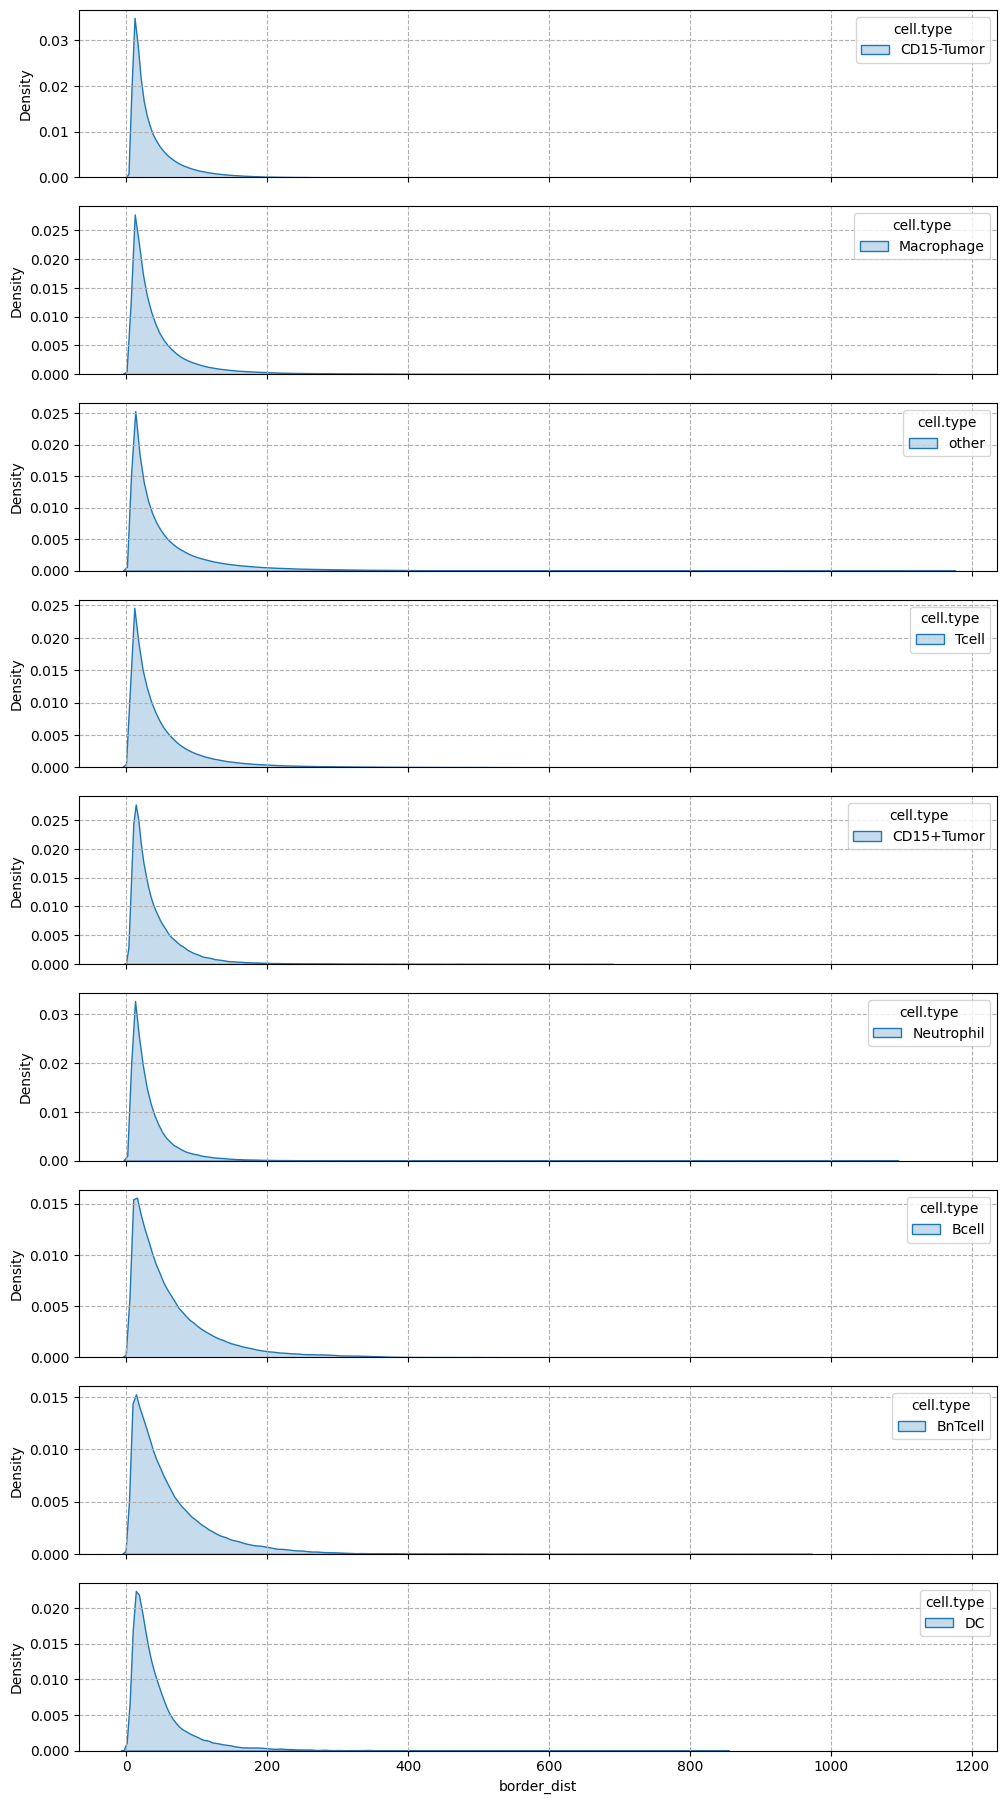

In [123]:
fig, axs = plt.subplots(num_uniq_celltypes, figsize=(10, 2 * num_uniq_celltypes), sharex=True)

fig.tight_layout()

for i, (ax, cell_type) in enumerate(zip(axs, df["cell.type"].unique())):
    configure_axis(ax)

    sns.kdeplot(
        ax = ax,
        data = df[(df['cell.type'] == cell_type) & (df["in.ROI.tumor_tissue"] == True)],
        x = "border_dist",
        fill=True,
        bw_adjust=0.5,
        hue = "cell.type"
    )


# Task 3

Compute a spatial infiltration profile: bin border_dist into 50 um bins; for each bin
compute the fraction of T cells among all cells in that bin. Plot fraction vs. distance for one
patient.

In [110]:
bins = np.arange(0, df["border_dist"].max() + 50, 50) 

df['dist_bin'] = pd.cut(df['border_dist'], bins=bins)

In [111]:
profile = df.groupby('dist_bin').apply(
    lambda g: (g['cell.type'] == 'Tcell').mean()
)

In [112]:
profile_df = profile.reset_index()
profile_df.columns = ['dist_bin', 'tcell_fraction']
profile_df['bin_mid'] = profile_df['dist_bin'].apply(lambda x: x.mid)
profile_df['bin_label'] = profile_df['dist_bin'].apply(lambda x: f"{int(x.left)}-{int(x.right)}")


profile_df

,dist_bin,tcell_fraction,bin_mid,bin_label
0,"(0.0, 50.0]",0.128536,25.0,0-50
1,"(50.0, 100.0]",0.143078,75.0,50-100
2,"(100.0, 150.0]",0.153569,125.0,100-150
3,"(150.0, 200.0]",0.164984,175.0,150-200
4,"(200.0, 250.0]",0.177587,225.0,200-250
5,"(250.0, 300.0]",0.189559,275.0,250-300
6,"(300.0, 350.0]",0.199654,325.0,300-350
7,"(350.0, 400.0]",0.200889,375.0,350-400
8,"(400.0, 450.0]",0.215299,425.0,400-450
9,"(450.0, 500.0]",0.222865,475.0,450-500


array([5546422, 5513756, 7346035, ..., 7420786, 8545287, 2563860],
      shape=(9988751,))

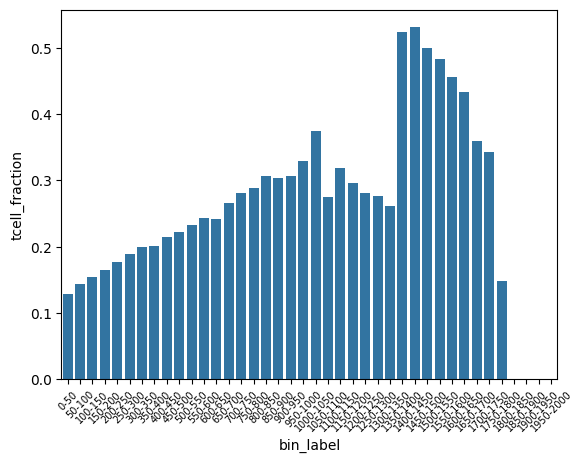

In [113]:
sns.barplot(data=profile_df, x='bin_label', y='tcell_fraction')
plt.xticks(rotation=45, fontsize=7)

_

# Task 4

Start: Define a per-patient T cell infiltration score as the median border_dist
of T cells that are inside the tumour ROI. A high positive score means T cells
penetrate deep into the tumour core; a score near zero means they are trapped at
the periphery. Compute this for all 15 patients and rank them

In [122]:
scores = (
    df[(df['cell.type'] == 'Tcell') & (df["in.ROI.tumor_tissue"] == True)]
    .groupby('patient_id')['border_dist']
    .median()
    .sort_values(ascending=False)
)

In [120]:
scores

patient_id
14    54.873035
5     43.126094
1     37.813225
13    37.051990
0     30.793668
4     29.689224
6     27.668394
9     27.136414
7     26.418554
11    25.083859
12    23.479779
10    20.934660
Name: border_dist, dtype: float64

# Bonus Task

Bonus: Plot the infiltration profiles (fraction vs. distance) for all 15 patients as a
grid of line plots. Do patients fall into visually distinct classes (infiltrated / excluded
/ mixed)? Fit a simple exponential decay f(d) = A * exp(-d / lambda) to each
profile and use the decay length lambda as a second, continuous infiltration score.
Compare it to the median-based score from Start.